# Кредитный скоринг: прогнозирование риска невозврата кредита

## Цель работы
Основная цель данного исследования — построение прогностической модели для оценки кредитного риска клиентов банка. В терминах машинного обучения это задача контролируемой бинарной классификации: по имеющимся характеристикам клиента необходимо предсказать значение целевой переменной Risk, где:

0 (good) — клиент выплатил кредит (надёжный заёмщик);

1 (bad) — клиент допустил невозврат (рисковый заёмщик).

Практическая значимость: Создание такой модели позволит банку автоматизировать скоринговый процесс, снизить долю "плохих" кредитов в портфеле и сократить операционные издержки на ручную проверку заявок. Модель будет использоваться для поддержки принятия решений: при поступлении новой заявки система будет выдавать вероятность дефолта, на основе которой кредитный инспектор сможет принять окончательное решение.

Задачи исследования:

1. Провести разведочный анализ данных (EDA), выявить закономерности и факторы, влияющие на риск.

2. Выполнить предобработку данных: обработать пропуски, закодировать категориальные признаки, при необходимости масштабировать числовые.

3. Построить несколько моделей классификации (логистическая регрессия, случайный лес, градиентный бустинг) и сравнить их качество.

4. Интерпретировать полученные результаты: определить ключевые факторы, влияющие на риск, и дать рекомендации для бизнеса.й:

## Описание исходных данных

В работе используется датасет "German Credit Risk", опубликованный на платформе Kaggle пользователем UCI Machine Learning.

Происхождение данных:
Оригинальный датасет был подготовлен профессором Хофманном и доступен в репозитории UCI Machine Learning Repository. Версия, используемая в данном проекте, представляет собой его адаптированную и упрощенную копию.

Модификации датасета:
Как указано на странице датасета на Kaggle, оригинальные данные содержали 20 категориальных атрибутов со сложной системой символов и категорий. Для повышения удобства использования была выполнена предобработка с помощью скрипта Python, в результате которой:

Оставлены только наиболее важные и интерпретируемые признаки (всего 10).

Категориальные значения заменены на понятные текстовые метки (например, 'male'/'female', 'own'/'rent'/'free').

Некоторые колонки, описание которых было неочевидным, были исключены.

Таким образом, структура данных в этом файле (10 признаков + целевая переменная) является результатом этой адаптации и полностью соответствует загруженному CSV-файлу.

Ссылки на источники:

Используемый датасет (Kaggle): [German Credit Risk](https://www.kaggle.com/datasets/uciml/german-credit)

Оригинальный датасет (UCI): [Statlog (German Credit Data)](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data))

## Загрузка и первичный анализ данных

In [367]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, fbeta_score, classification_report, make_scorer, recall_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [112]:
df = pd.read_csv('data/german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


**Описание колонок:**

| Признак | Описание | Тип |
|---------|----------|-----|
| **Age** | Возраст клиента (годы) | количественный |
| **Sex** | Пол (male/female) | категориальный |
| **Job** | Уровень квалификации (0 — неквалифицированный нерезидент, 1 — неквалифицированный резидент, 2 — квалифицированный, 3 — высококвалифицированный) | ранговый |
| **Housing** | Тип жилья (own — своё, rent — аренда, free — бесплатное) | категориальный |
| **Saving accounts** | Наличие сбережений (little, moderate, quite rich, rich) | ранговый |
| **Checking account** | Состояние текущего счета (little, moderate, rich) | ранговый |
| **Credit amount** | Сумма кредита (в немецких марках) | количественный |
| **Duration** | Срок кредита (месяцы) | количественный |
| **Purpose** | Цель кредита (car, radio/TV, education и др.) | категориальный |
| **Risk** | Целевая переменная (good — кредит выплачен, bad — невозврат) | бинарный |

Данные содержат пропуски в колонках `Saving accounts` и `Checking account`, которые будут обработаны в ходе анализа.

Проверим распределение целевого признака

In [114]:
df.Risk.value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

Сразу можем заметить, что данные несбалансированы ('bad' встречается примерно в 2 раза реже, чем 'good'). При построении модели, необходимо будет это учесть

Первый столбец соответствует индексу строки, поэтому можем его удалить

In [115]:
df.drop(columns='Unnamed: 0', inplace=True)

Переведем признак Risk в числовой формат для бинарной классификации (0 - нет риска, 1 - риск есть)

In [116]:
df = df.assign(is_risk=(df.Risk == 'bad').astype(int)).drop(columns='Risk')
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,is_risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,0
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,0
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1


In [117]:
df.isna().mean()

Age                 0.000
Sex                 0.000
Job                 0.000
Housing             0.000
Saving accounts     0.183
Checking account    0.394
Credit amount       0.000
Duration            0.000
Purpose             0.000
is_risk             0.000
dtype: float64

**Наблюдение:** В колонках Saving accounts и Checking account есть пропуски 
(18% и 39% соответственно). Это значительная доля данных, поэтому просто 
удалять строки нельзя.

## Разведочный анализ (EDA) с учетом пропусков

### Анализ пропусков

Посмотрим долю риска для каждой категории и для пропущенных значений

In [118]:
df.groupby('Checking account')['is_risk'].mean()

Checking account
little      0.492701
moderate    0.390335
rich        0.222222
Name: is_risk, dtype: float64

In [119]:
df[df['Checking account'].isna()].is_risk.mean()

np.float64(0.116751269035533)

In [120]:
df.groupby('Saving accounts')['is_risk'].mean()

Saving accounts
little        0.359867
moderate      0.330097
quite rich    0.174603
rich          0.125000
Name: is_risk, dtype: float64

In [121]:
df[df['Saving accounts'].isna()].is_risk.mean()

np.float64(0.17486338797814208)

Исследование показало, что пропуски в данных неслучайны и несут важную информацию:

1. **Checking account**:
   - Клиенты с малым остатком (little) имеют максимальный риск (49%)
   - Наличие богатого счета (rich) снижает риск до 22%
   - **Пропуски соответствуют минимальному риску (11.7%)** — вероятно, эти клиенты либо не имеют счета в этом банке, либо по каким-то причинам скрывают информацию, но статистически это самая надежная группа

2. **Saving accounts**:
   - Четкая обратная зависимость: больше сбережений - ниже риск
   - Пропуски (17.5%) близки к группе quite rich (17.4%), что может указывать на состоятельных клиентов, не указавших детали

Пропуски следует заменить на отдельную категорию 'unknown', чтобы модель могла самостоятельно обучиться на этих паттернах. Это позволит сохранить информацию о низкорисковых клиентах с пропусками в Checking account и среднерисковых в Saving accounts.

In [122]:
df.fillna('unknown', inplace=True)

In [123]:
df.isna().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
is_risk             0
dtype: int64

### Исследование категориальных признаков

In [124]:
df.select_dtypes(include='object').describe()

,Sex,Housing,Saving accounts,Checking account,Purpose
count,1000,1000,1000,1000,1000
unique,2,3,5,4,8
top,male,own,little,unknown,car
freq,690,713,603,394,337


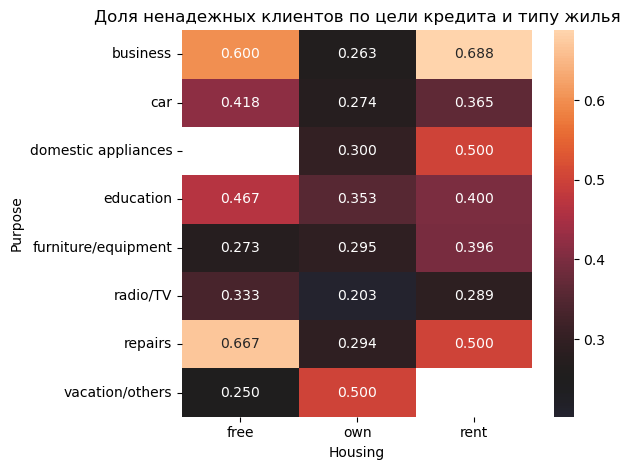

In [125]:
pivot_mean = df.pivot_table(index='Purpose', columns='Housing', values='is_risk', aggfunc='mean')

sns.heatmap(pivot_mean, annot=True, center=0.25, fmt='.3f')
plt.title('Доля ненадежных клиентов по цели кредита и типу жилья')
plt.tight_layout()
plt.show()

Выводы:
1. Наибольший риск наблюдается у клиентов, берущих кредит на бизнес и арендующих жилье (68%)
2. Самые надежные — клиенты с кредитом на радио/ТВ и собственным жильем (20%)
3. Чаще всего клиенты с собственных жильем (own) имеют меньший риск

In [126]:
column='Purpose'
result = (
    df
    .groupby(column, as_index=False)
    .agg({'is_risk': ['mean', 'size']})
    .droplevel(level=0, axis=1)
    .rename(
        {
            '': column, 
            'mean': 'risk_level', 
            'size': 'clients_count'
        }, axis=1)
    .sort_values(by='risk_level', ascending=False)
)
for i, (_, row) in enumerate(result.iterrows()):
    print(result)
    break

               Purpose  risk_level  clients_count
7      vacation/others    0.416667             12
3            education    0.389831             59
6              repairs    0.363636             22
0             business    0.350515             97
2  domestic appliances    0.333333             12
4  furniture/equipment    0.320442            181
1                  car    0.314540            337
5             radio/TV    0.221429            280


In [127]:
def calc_risks(column):
    '''
    Функция позволяет рассчитать среднее значение рискованности для группы пользователей.
    '''
    return (
        df
        .groupby(column, as_index=False)
        .agg({'is_risk': ['mean', 'size']})
        .droplevel(level=0, axis=1)
        .rename(
            {
                '': column, 
                'mean': 'risk_level', 
                'size': 'clients_count'
            }, axis=1)
        .sort_values(by='risk_level', ascending=False)
    )

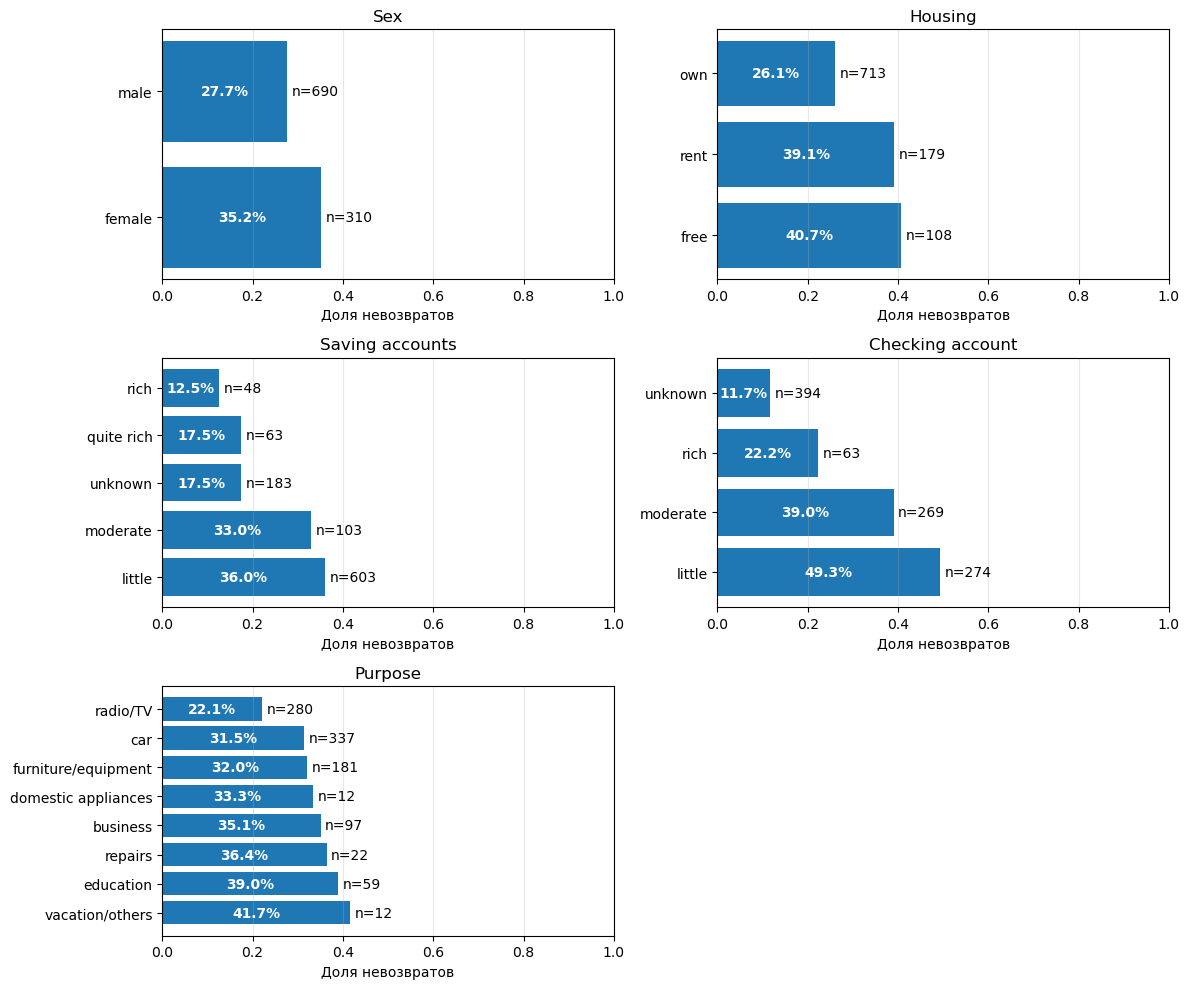

In [128]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

object_cols = df.select_dtypes(include='object').columns

for i, column in enumerate(object_cols):
    data = calc_risks(column)
    
    # Строим график на axes[i]
    axes[i].barh(data[column], data['risk_level'])
    axes[i].set_xlabel('Доля невозвратов')
    axes[i].set_title(f'{column}')
    axes[i].set_xlim(0, 1)
    
    for j, (_, row) in enumerate(data.iterrows()):
        axes[i].text(row['risk_level'] + 0.01, j, 
                    f"n={row['clients_count']}", va='center')
        axes[i].text(row['risk_level']/2, j,
                    f'{row['risk_level']:.1%}', color='white',
                     weight='bold',
                     va='center', ha='center')
    
    axes[i].grid(axis='x', alpha=0.3)

# Скрываем лишние
for j in range(len(object_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Анализ категориальных переменных выявил четкие закономерности, влияющие на кредитный риск:

1. Финансовые признаки — ключевые предикторы:

Состояние текущего счета (Checking account) — самый сильный фактор. Риск снижается с ростом остатка на счете (49% → 22%). Важное открытие: клиенты с пропущенными данными ('unknown') имеют минимальный риск (12%), что указывает на информативность пропусков.

Наличие сбережений (Saving accounts) — обратная зависимость: чем больше сбережений, тем ниже риск (36% → 13%). Пропуски близки к группе 'quite rich'.

2. Социально-демографические признаки также значимы:

Тип жилья (Housing) — собственное жилье ('own') дает риск 26%, аренда ('rent') и бесплатное ('free') — около 40%.

Пол (Sex) — мужчины надежнее женщин (28% против 35%).

Цель кредита (Purpose) — наибольший риск у кредитов на отдых (42%) и образование (39%), наименьший — на радио/ТВ (22%).

Главный вывод: Наибольшее влияние на риск оказывают финансовые характеристики клиента (состояние счета и сбережения), а также тип жилья. Пропуски в данных несут важную информацию и должны быть сохранены как отдельная категория при построении модели.

### Исследование числовых признаков

In [129]:
df.describe()

,Age,Job,Credit amount,Duration,is_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000,0.300000
std,11.375469,0.653614,2822.736876,12.058814,0.458487
min,19.000000,0.000000,250.000000,4.000000,0.000000
25%,27.000000,2.000000,1365.500000,12.000000,0.000000
50%,33.000000,2.000000,2319.500000,18.000000,0.000000
75%,42.000000,2.000000,3972.250000,24.000000,1.000000
max,75.000000,3.000000,18424.000000,72.000000,1.000000


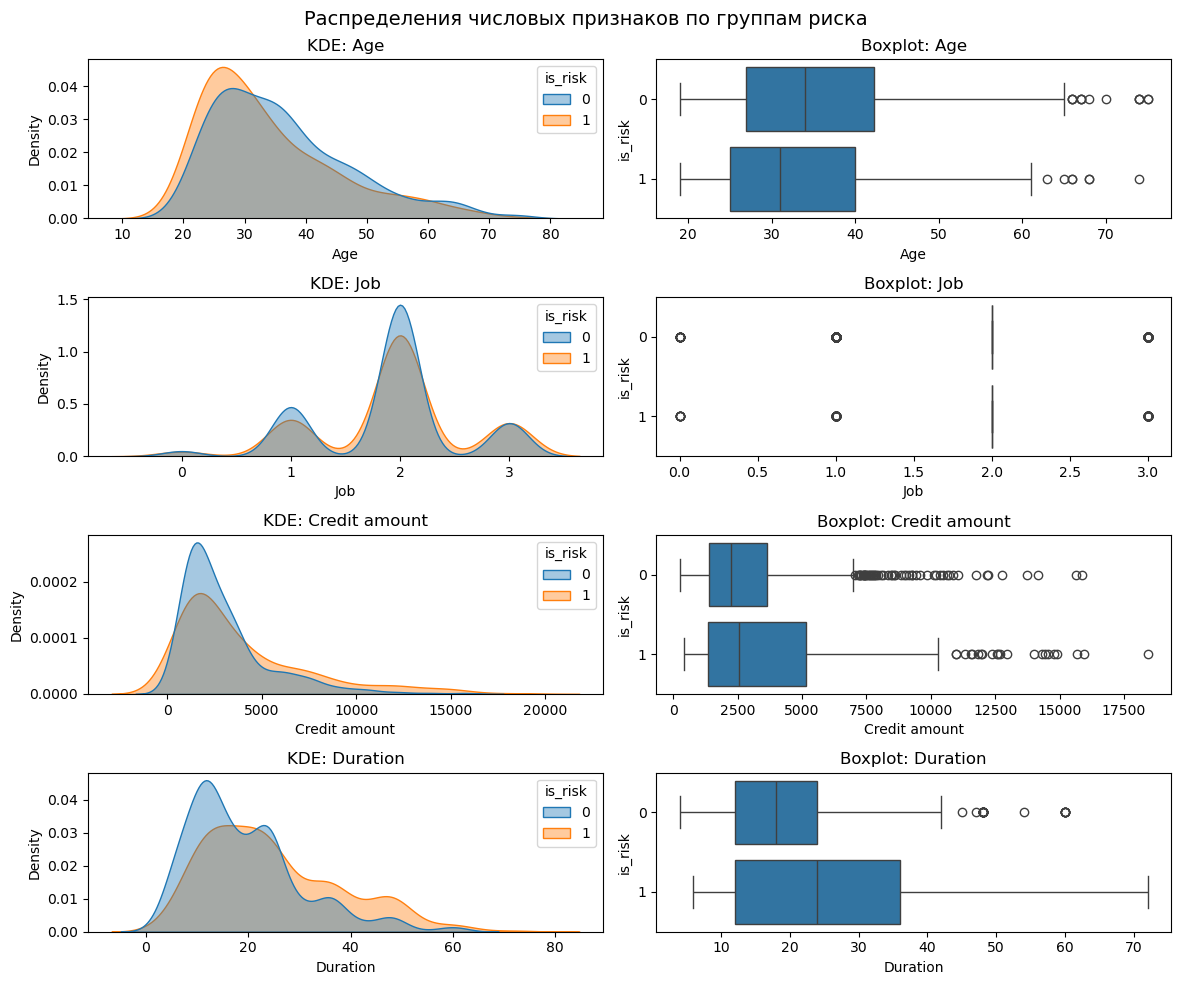

In [130]:
num_cols = df.drop(columns='is_risk').select_dtypes('number').columns
fig, axes = plt.subplots(4, 2, figsize=(12, 10))

for i, col in enumerate(num_cols):
    
    sns.kdeplot(data=df, x=col, hue='is_risk', common_norm=False,
                fill=True, alpha=0.4, ax=axes[i, 0])
    axes[i, 0].set_title(f'KDE: {col}')
    
    sns.boxplot(data=df, orient='h', x=col, y='is_risk', ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot: {col}')

plt.suptitle('Распределения числовых признаков по группам риска', fontsize=14)
plt.tight_layout()


Вывод:
1. **Сумма и срок кредита** — наиболее информативные количественные признаки. Плохие клиенты в среднем берут кредиты на более высокую сумму и долгий срок.

2. **Возраст** имеет слабую связь: молодые клиенты чуть рискованнее, но разница небольшая.

3. **Уровень квалификации (Job)** практически не влияет на риск в данной выборке — распределение почти идентично.

4. **Важно:** Для суммы и срока наблюдается не только смещение средних, но и больший разброс значений в группе риска (видны на боксплотах).

**Что важно учесть при построении модели прогнозирования:** 
- Сумму и срок кредита обязательно оставить как есть (они информативны)
- Возраст можно либо оставить, либо разбить на категории (биннинг)
- Job можно использовать, но его вклад будет минимальным

### Оценка важности признаков с помощью метода WoE / IV

Для начала разобьем числовые признаки по бинам

In [131]:
def calc_woe_by_column(df, column):
    
    grouped = df.groupby(column, observed=False).agg(bad=('is_risk', 'sum'), total=('is_risk', 'count'))
    grouped['good'] = grouped['total'] - grouped['bad']
    
    n_good = grouped['good'].sum()
    n_bad = grouped['bad'].sum()

    grouped['WoE'] = np.round(np.log((grouped['bad'] / n_bad) / (grouped['good'] / n_good)), 3)
    grouped = grouped.replace([np.inf, -np.inf], np.nan)

    return grouped[['bad', 'good', 'WoE']].sort_values(by='WoE', ascending=False)

def get_IV(df, column):
    woe = calc_woe_by_column(df, column)
    return ((woe.bad / woe.bad.sum() - woe.good / woe.good.sum()) * woe.WoE).sum()

In [132]:
features = df.drop(columns=['Credit amount', 'Duration', 'Age'])

# Возраст
age_bins = [0, 25, 35, 45, 60, 100]
features['age_bin'] = pd.cut(
    df['Age'], 
    bins=age_bins, 
    labels=['<25', '25-35', '35-45', '45-60', '60+']
)

# Сумма кредита (по квантилям)
features['amount_bin'] = pd.qcut(
    df['Credit amount'], 
    q=5,
    labels=['very low', 'low', 'medium', 'high', 'very high']
)

# Срок кредита
duration_bins = [0, 11, 24, 36, 100]
features['duration_bin'] = pd.cut(
    df['Duration'], 
    bins=duration_bins,
    labels=['<1 year', '1-2 years', '2-3 years', '3+ years']
)

features.head()

,Sex,Job,Housing,Saving accounts,Checking account,Purpose,is_risk,age_bin,amount_bin,duration_bin
0,male,2,own,unknown,little,radio/TV,0,60+,very low,<1 year
1,female,2,own,little,moderate,radio/TV,1,<25,very high,3+ years
2,male,1,own,little,unknown,education,0,45-60,medium,1-2 years
3,male,2,free,little,little,furniture/equipment,0,35-45,very high,3+ years
4,male,2,free,little,little,car,1,45-60,very high,1-2 years


In [133]:
for col in features.columns.drop('is_risk'):
    print(f'\nFeature: {col}\n----------------------------')
    print(calc_woe_by_column(features, col))


Feature: Sex
----------------------------
        bad  good    WoE
Sex                     
female  109   201  0.235
male    191   499 -0.113

Feature: Job
----------------------------
     bad  good    WoE
Job                  
3     51    97  0.204
0      7    15  0.085
2    186   444 -0.023
1     56   144 -0.097

Feature: Housing
----------------------------
         bad  good    WoE
Housing                  
free      44    64  0.473
rent      70   109  0.404
own      186   527 -0.194

Feature: Saving accounts
----------------------------
                 bad  good    WoE
Saving accounts                  
little           217   386  0.271
moderate          34    69  0.140
unknown           32   151 -0.704
quite rich        11    52 -0.706
rich               6    42 -1.099

Feature: Checking account
----------------------------
                  bad  good    WoE
Checking account                  
little            135   139  0.818
moderate          105   164  0.401
rich            

In [134]:
iv_series = pd.Series({f: get_IV(features, f) for f in features.columns.drop('is_risk')}, name='IV')
iv_series.sort_values(ascending=False)

Checking account    0.665840
duration_bin        0.227157
Saving accounts     0.195941
amount_bin          0.093377
age_bin             0.086989
Housing             0.083260
Purpose             0.067310
Sex                 0.026514
Job                 0.008750
Name: IV, dtype: float64

### Выводы

1. **Ранжирование признаков по силе влияния на риск (IV)**

| Уровень влияния                      | Признаки         | IV    | Интерпретация         |
| ------------------------------------ | ---------------- | ----- | --------------------- |
| **Очень сильное** (IV > 0.3)         | Checking account | 0.666 | Основной фактор риска |
| **Сильное/среднее** (0.1 < IV ≤ 0.3) | duration_bin     | 0.227 | Важный фактор риска   |
|                                      | Saving accounts  | 0.196 | Важный фактор риска   |
| **Среднее/слабое** (0.05 < IV ≤ 0.1) | amount_bin       | 0.093 | Умеренное влияние     |
|                                      | age_bin          | 0.087 | Умеренное влияние     |
|                                      | Housing          | 0.083 | Умеренное влияние     |
|                                      | Purpose          | 0.067 | Умеренное влияние     |
| **Слабое** (IV ≤ 0.03)               | Sex              | 0.027 | Минимальное влияние   |
|                                      | Job              | 0.009 | Практически не влияет |

---

2. **Факторы, повышающие риск (WoE > 0.5)**

Наибольший риск наблюдается у клиентов с:

* **Проверка счета: little** (WoE = 0.818) — сильно рискованная категория
* **Срок кредита более 3 лет** (duration_bin = 3+ years, WoE = 0.916)
* **Возраст до 25 лет** (age_bin <25, WoE = 0.529)
* **Очень высокая сумма кредита** (amount_bin = very high, WoE = 0.545)

---

3. **Факторы, снижающие риск (WoE < -0.5)**

Наиболее безопасные клиенты:

* **Срок кредита менее 1 года** (duration_bin <1 year, WoE = -0.887)
* **Отсутствие данных о текущем счете** (Checking account = unknown, WoE = -1.176) — самая надёжная группа
* **Богатые сбережения** (Saving accounts = rich, WoE = -1.099)
* **Возраст старше 60 лет** (age_bin 60+, WoE = -0.405)

## Разработка моделей прогнозирования

### Используемые алгоритмы
Для решения задачи кредитного скоринга были выбраны пять алгоритмов машинного обучения, представляющих различные подходы к классификации:

Логистическая регрессия выбрана в качестве базовой модели благодаря высокой интерпретируемости и прозрачности принимаемых решений. В кредитном скоринге способность объяснить причины отказа является критическим требованием, и логистическая регрессия позволяет напрямую оценить влияние каждого признака на итоговую вероятность.

Случайный лес представляет собой ансамблевый метод, устойчивый к переобучению и эффективно работающий на небольших выборках. Алгоритм способен выявлять сложные нелинейные зависимости и взаимодействия между признаками, что важно для кредитного скоринга.

XGBoost выбран как один из наиболее мощных алгоритмов градиентного бустинга, показывающий высокое качество на табличных данных. Метод хорошо работает с разреженными матрицами после one-hot кодирования и имеет встроенные механизмы регуляризации.

LightGBM включен в сравнение благодаря высокой скорости обучения. Алгоритм использует односторонний отбор градиента, что ускоряет обучение без потери качества.

CatBoost добавлен в сравнение как современный градиентный бустинг, который показывает высокое качество "из коробки" и не требует сложной настройки гиперпараметров, что делает его привлекательным для практического применения в задачах кредитного скоринга.

### Выбор метрик

Для оценки качества моделей использованы следующие метрики:

ROC-AUC выбрана в качестве основной метрики, оценивающей способность модели разделять классы вне зависимости от выбранного порога классификации. Это стандартная метрика для задач бинарной классификации, устойчивая к дисбалансу классов.

F-beta с β=2 является ключевой бизнес-метрикой, где полноте (recall) присвоен больший вес, чем точности (precision). В кредитном скоринге пропустить плохого клиента (false negative) обходится дороже, чем ошибочно отказать хорошему (false positive). Коэффициент β=2 означает, что полнота считается в два раза важнее точности, что соответствует бизнес-логике задачи.

Порог классификации (threshold) оптимизируется индивидуально для каждой модели. Выбор оптимального порога позволяет настроить чувствительность модели в соответствии с бизнес-требованиями и максимизировать F-beta метрику на валидационной выборке.

### Подготовка данных

In [240]:
X = df.drop(columns='is_risk')
y = df.is_risk

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=123
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=123
)

print('Размеры выборок (train/val/test): {}/{}/{}'.format(len(X_train), len(X_val), len(X_test)))

Размеры выборок (train/val/test): 850/75/75


**Кодирование категориальных признаков**

Для кодирования категориальных признаков будем использовать OrdinalEncoder, так как он, в отличие от One-Hot Encoding, не увеличивает размерность данных и сохраняет интерпретируемость. Поскольку мы будем использовать деревянные модели, которые не чувствительны к масштабу признаков и не интерпретируют числа как расстояния, такой подход является оптимальным.

In [328]:
categorical_transformer = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
preprocessor = ColumnTransformer([
    ('cat', categorical_transformer, object_cols),
], remainder='passthrough')

preprocessor.set_output(transform="pandas")

X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)
X_test_encoded = preprocessor.transform(X_test)

X_val_encoded.head()

,cat__Sex,cat__Housing,cat__Saving accounts,cat__Checking account,cat__Purpose,remainder__Age,remainder__Job,remainder__Credit amount,remainder__Duration
589,1.0,1.0,0.0,0.0,4.0,60,2,2246,12
465,1.0,1.0,0.0,0.0,1.0,63,2,2924,24
759,1.0,1.0,0.0,0.0,1.0,35,2,691,12
777,0.0,1.0,0.0,0.0,5.0,25,2,3509,18
442,1.0,1.0,0.0,1.0,7.0,29,2,2629,20


In [329]:
X_train_encoded.columns = object_cols.to_list() + num_cols.to_list()
X_val_encoded.columns = object_cols.to_list() + num_cols.to_list()
X_test_encoded.columns = object_cols.to_list() + num_cols.to_list()

X_val_encoded.head()

,Sex,Housing,Saving accounts,Checking account,Purpose,Age,Job,Credit amount,Duration
589,1.0,1.0,0.0,0.0,4.0,60,2,2246,12
465,1.0,1.0,0.0,0.0,1.0,63,2,2924,24
759,1.0,1.0,0.0,0.0,1.0,35,2,691,12
777,0.0,1.0,0.0,0.0,5.0,25,2,3509,18
442,1.0,1.0,0.0,1.0,7.0,29,2,2629,20


### Baseline

В качестве бейзлайна возьмем логистическую регрессию.

In [433]:
def roc_curve_plot(y_true, y_score, ax=None):

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    
    ax.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC-кривая')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

              precision    recall  f1-score   support

           0       0.82      0.60      0.69        52
           1       0.43      0.70      0.53        23

    accuracy                           0.63        75
   macro avg       0.62      0.65      0.61        75
weighted avg       0.70      0.63      0.64        75

ROC-AUC: 0.7240802675585284
F-beta: 0.6201550387596899


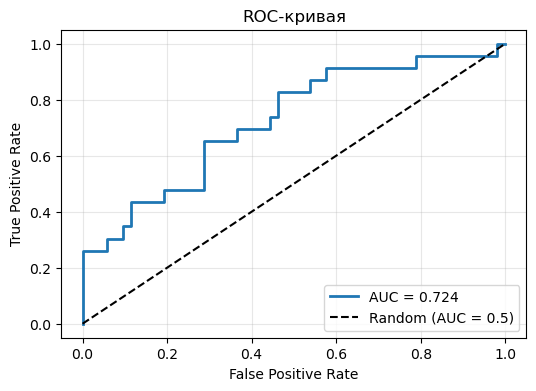

In [434]:
preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(), object_cols),
    ('scaler', StandardScaler(), num_cols)
])
log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=123))
])

log_reg.fit(X_train, y_train)
val_pred = log_reg.predict(X_val)
val_probs = log_reg.predict_proba(X_val)[:, 1]

print(classification_report(y_val, val_pred))
print('ROC-AUC:', roc_auc_score(y_val, val_probs))
print('F-beta:', fbeta_score(y_val, val_pred, beta=2))

roc_curve_plot(y_val, val_probs)

### Сравнение разных моделей

In [182]:
def optimize_fbeta(y_true, y_pred_proba, beta=2.0):
    """
    Фукнция подбирает оптимальный порог (threshold) по метрике F-beta
    F-beta с beta>1 дает больший вес recall
    """
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_score = 0
    best_thresh = 0.5
    
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta)
        
        if score > best_score:
            best_score = score
            best_thresh = thresh
    
    return best_thresh, best_score

Мы ограничили порог 0.1, чтобы избежать слишком большого числа false positives.

На начальном этапе были обучены модели без подбора гиперпараметров. Результаты представлены ниже:

In [331]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=123),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=123),  
    'LightGBM': LGBMClassifier(class_weight='balanced', random_state=123, verbose=-1),
    'CatBoost': CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_state=123)
}

results = {}
for name, model in models.items():
    model.fit(X_train_encoded, y_train)
    
    y_pred_proba = model.predict_proba(X_val_encoded)[:, 1]
    thresh, fbeta = optimize_fbeta(y_val, y_pred_proba)
    
    results[name] = [roc_auc_score(y_val, y_pred_proba), fbeta, thresh]

results = pd.DataFrame(
    list(results.values()), 
    index=models.keys(),
    columns=['ROC-AUC', 'F-beta', 'threshold']
)

results

,ROC-AUC,F-beta,threshold
RandomForest,0.757107,0.735294,0.19
XGBoost,0.736622,0.630252,0.22
LightGBM,0.718227,0.625000,0.10
CatBoost,0.731605,0.677419,0.10


### Анализ результатов

1. **ROC-AUC**

Наибольшее значение ROC-AUC показал **RandomForest (0.757)**, что говорит о наилучшей способности различать клиентов по уровню риска.

**XGBoost (0.737)**, **LightGBM (0.718)** и **CatBoost (0.731)** демонстрируют близкие результаты, немного уступая RandomForest.

Таким образом, с точки зрения **способности ранжировать клиентов по риску**, RandomForest является текущим лидером.

---

2. **F-beta (β=2)**

По метрике F-beta наилучший результат снова показал **RandomForest (0.735)**, что указывает на оптимальный баланс между полнотой (**recall**) и точностью (**precision**) для дефолтного класса.

**CatBoost (0.677)** так же показал неплохой результат, а **LightGBM (0.625)** и **XGBoost (0.630)** демонстрирует наименее удачный баланс recall и precision для целевого класса.

---

**Общий вывод**

На данном этапе целесообразно сосредоточиться на **RandomForest и CatBoost**, так как они показывают наиболее сбалансированные результаты по ключевым метрикам. После дополнительной настройки гиперпараметров можно будет сделать окончательный выбор финальной модели и провести углубленный анализ влияния признаков.

### Подбор гиперпараметров и выбор финальной модели

In [290]:
f2_scorer = make_scorer(fbeta_score, beta=2)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

#### RandomForest

In [392]:
rf_model = models['RandomForest']

rf_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5, 0.7]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_dist,
    n_iter=50,
    scoring=f2_scorer,
    cv=cv,
    random_state=123,
    n_jobs=-1
)

rf_search.fit(X_train_encoded, y_train)

print("RandomForest best params:", rf_search.best_params_)
print("RandomForest CV F2:", rf_search.best_score_)

RandomForest best params: {'max_depth': 4, 'max_features': 0.3, 'min_samples_leaf': 9, 'min_samples_split': 13, 'n_estimators': 494}
RandomForest CV F2: 0.6849663530598822


              precision    recall  f1-score   support

           0       0.92      0.42      0.58        52
           1       0.41      0.91      0.57        23

    accuracy                           0.57        75
   macro avg       0.66      0.67      0.57        75
weighted avg       0.76      0.57      0.58        75

ROC-AUC: 0.7441471571906355
F-beta: 0.7342657342657343


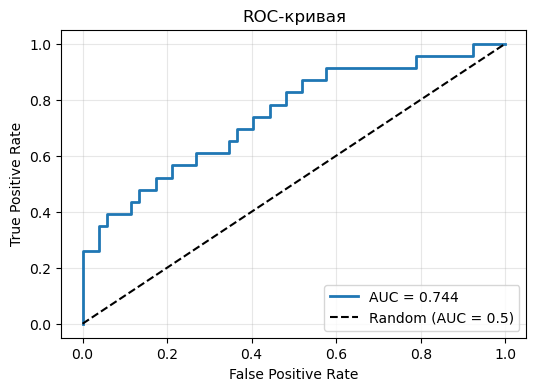

In [435]:
rf_model = rf_search.best_estimator_

val_probs = rf_model.predict_proba(X_val_encoded)[:, 1]
thresh, fbeta = optimize_fbeta(y_val, val_probs)
val_pred = val_probs >= thresh

print(classification_report(y_val, val_pred))
print('ROC-AUC:', roc_auc_score(y_val, val_probs))
print('F-beta:', fbeta_score(y_val, val_pred, beta=2))

roc_curve_plot(y_val, val_probs)

| Модель | ROC-AUC | F-beta |
|--------|---------|--------|
| Logistic Regression (baseline) | 0.724 | 0.620 |
| Random Forest (до оптимизации) | 0.757 | 0.735 |
| Random Forest (после оптимизации) | 0.744 | 0.734 |

**Анализ:**

Подбор гиперпараметров методом RandomizedSearchCV не улучшил качество модели случайного леса - это говорит о том, что исходные параметры уже являются оптимальными

#### CatBoost

In [294]:
cat_model = models['CatBoost']

cat_param_dist = {
    'iterations': randint(300, 800),
    'depth': randint(3, 10),
    'learning_rate': uniform(0.05, 0.1),
    'l2_leaf_reg': uniform(1, 10)
}

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cat_param_dist,
    n_iter=10,
    scoring=f2_scorer,
    cv=cv,
    random_state=123,
    n_jobs=-1
)

cat_search.fit(X_train, y_train, cat_features=object_cols.to_list())

print("CatBoost best params:", cat_search.best_params_)
print("CatBoost CV F2:", cat_search.best_score_)

CatBoost best params: {'depth': 4, 'iterations': 376, 'l2_leaf_reg': np.float64(7.309761238544878), 'learning_rate': np.float64(0.05921049399450752)}
CatBoost CV F2: 0.6386362248790142


              precision    recall  f1-score   support

           0       0.88      0.29      0.43        52
           1       0.36      0.91      0.52        23

    accuracy                           0.48        75
   macro avg       0.62      0.60      0.48        75
weighted avg       0.72      0.48      0.46        75

ROC-AUC: 0.7508361204013378
F-beta: 0.7


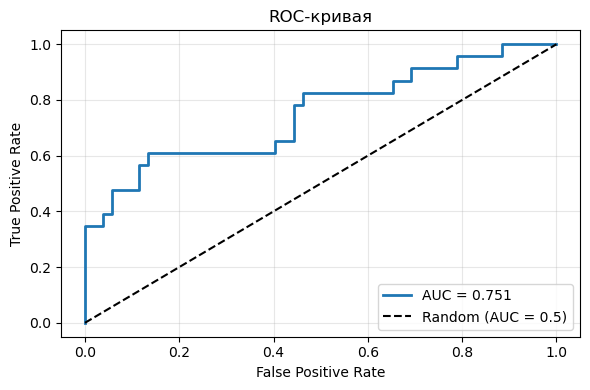

In [395]:
cat_model = cat_search.best_estimator_

val_probs = cat_model.predict_proba(X_val)[:, 1]
thresh, fbeta = optimize_fbeta(y_val, val_probs)
val_pred = val_probs >= thresh

print(classification_report(y_val, val_pred))
print('ROC-AUC:', roc_auc_score(y_val, val_probs))
print('F-beta:', fbeta_score(y_val, val_pred, beta=2))

roc_curve_plot(y_val, val_probs)

После оптимизации гиперпараметров удалось улучшить метрики модели CatBoost, но они все еще не превысили показатели RandomForest

### RandomForest с исходными параметрами

              precision    recall  f1-score   support

           0       0.90      0.54      0.67        52
           1       0.45      0.87      0.60        23

    accuracy                           0.64        75
   macro avg       0.68      0.70      0.64        75
weighted avg       0.77      0.64      0.65        75

ROC-AUC: 0.7571070234113713
F-beta: 0.7352941176470589


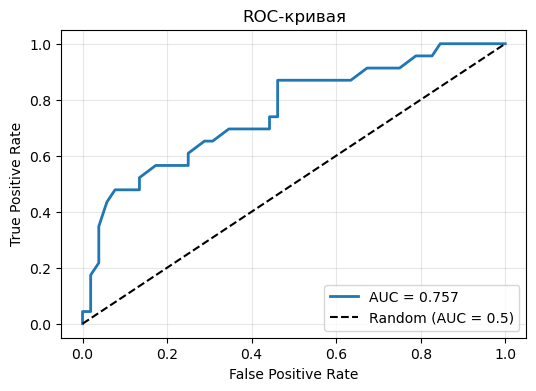

In [436]:
rf_model = models['RandomForest']

val_probs = rf_model.predict_proba(X_val_encoded)[:, 1]
thresh, fbeta = optimize_fbeta(y_val, val_probs)
val_pred = val_probs >= thresh

print(classification_report(y_val, val_pred))
print('ROC-AUC:', roc_auc_score(y_val, val_probs))
print('F-beta:', fbeta_score(y_val, val_pred, beta=2))

roc_curve_plot(y_val, val_probs)

### Сравнение Random Forest и CatBoost

Наилучшие результаты

| Модель | ROC-AUC | F-beta | 
|--------|---------|--------|
| **Random Forest** | **0.757** | **0.735** |
| **CatBoost** | 0.751 | 0.700 | 

Анализ

**F-beta**: Random Forest демонстрирует лучшее значение целевой метрики F-beta (0.735 против 0.700), что критически важно для задачи кредитного скоринга с приоритетом полноты выявления рисковых клиентов.

**ROC-AUC**: обе модели показали хорошие результаты, но RandomForest снова оказался немного лучше (0.757 против 0.751)

В качестве финальной модели выбран **Random Forest**

## Feature Importance для RandomForest

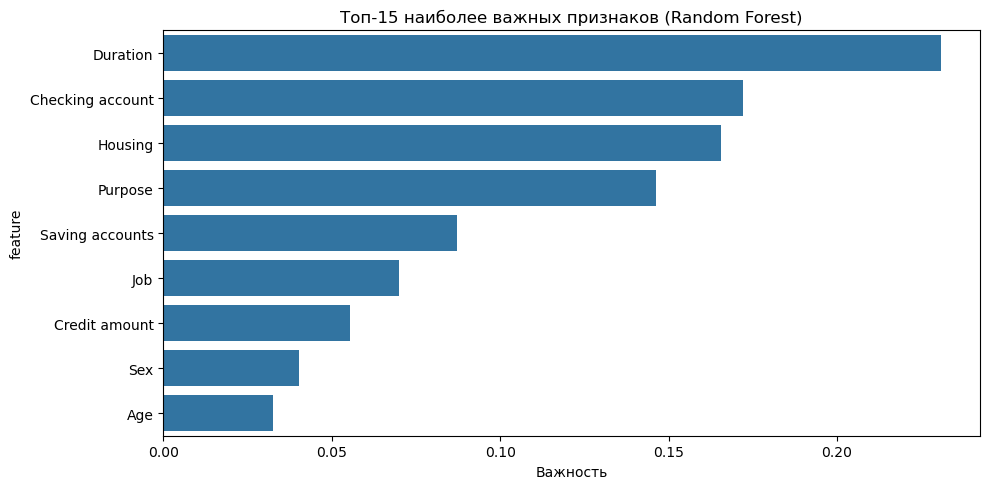

         feature  importance
        Duration    0.230891
Checking account    0.171992
         Housing    0.165514
         Purpose    0.146163
 Saving accounts    0.087199
             Job    0.070058
   Credit amount    0.055304
             Sex    0.040209
             Age    0.032669


In [350]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

top_features = feature_importance

plt.figure(figsize=(10, 5))
sns.barplot(data=top_features, y='feature', x='importance')
plt.title('Топ-15 наиболее важных признаков (Random Forest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))

Сравнение важности признаков, полученной из модели Random Forest, с результатами WoE/IV анализа показывает следующее:

**Ключевые совпадения:**
- **Duration** остается в топ-2 наиболее важных признаков в обоих анализах
- **Checking account** подтверждает свою высокую значимость (1 место по IV, 2 место в модели)

**Наблюдаемые расхождения:**
- **Housing** и **Purpose** получили более высокую важность в модели (3-4 места) по сравнению с IV (6-7 места), что может объясняться способностью Random Forest улавливать их взаимодействия (например, Purpose × Housing)
- **Age** и **Credit amount**, напротив, потеряли позиции, вероятно, из-за того, что их влияние частично перекрывается другими признаками

**Вывод:** Feature importance Random Forest в целом сохраняет логику, выявленную в EDA. Небольшие перестановки в середине списка объясняются учетом взаимодействий между признаками и не противоречат бизнес-логике.

Проведенная оптимизация гиперпараметров XGBoost с использованием RandomizedSearchCV и кросс-валидации по метрике F-beta (β=2) позволила получить следующие результаты на валидационной выборке.

Модель демонстрирует ROC-AUC 0.732, что подтверждает ее хорошую способность разделять классы. При этом F-beta достиг значения 0.710, что существенно выше показателей до оптимизации и приближается к уровню лучших моделей.

Распределение важности признаков в оптимизированной модели XGBoost демонстрирует высокую согласованность с выводами разведочного анализа и бизнес-логикой кредитного скоринга.

Наибольшую важность получили признаки, связанные со сбережениями клиента: категория unknown в Saving accounts занимает первое место с существенным отрывом, что подтверждает вывод EDA о том, что отсутствие информации о сбережениях является важным сигналом. Категории moderate и quite rich также вошли в топ-3, что полностью соответствует обратной зависимости между размером сбережений и уровнем риска, выявленной на этапе анализа.

Положительным моментом является то, что исходные числовые признаки Credit amount, Duration и Age получили умеренные, но значимые веса, что говорит о том, что модель использует как бинарные версии, так и исходные значения.

Обращает на себя внимание низкая важность признаков Checking account, особенно категории little, которая по данным EDA имела максимальный риск. Это может указывать на то, что информация о текущем счете оказалась менее значимой в контексте взаимодействия с другими признаками, либо эффект этой переменной уже учтен через другие характеристики клиента.

Категории Purpose распределились равномерно, без доминирования редких категорий, что выгодно отличает XGBoost от Random Forest. Нулевая важность для некоторых категорий Purpose (education, domestic appliances) объясняется малым количеством наблюдений и отсутствием устойчивых паттернов.

## Анализ SHAP-графиков для RandomForest

Для более глубокого понимания того, как модель принимает решения, был использован метод SHAP, который позволяет оценить вклад каждого признака в конкретное предсказание.

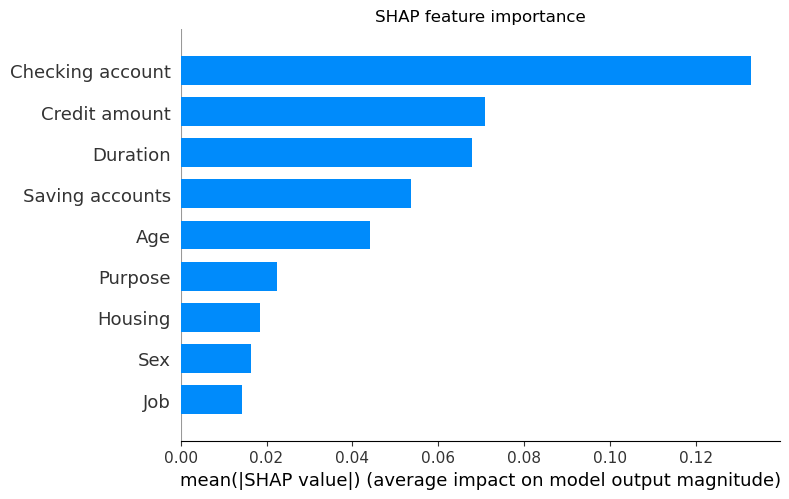

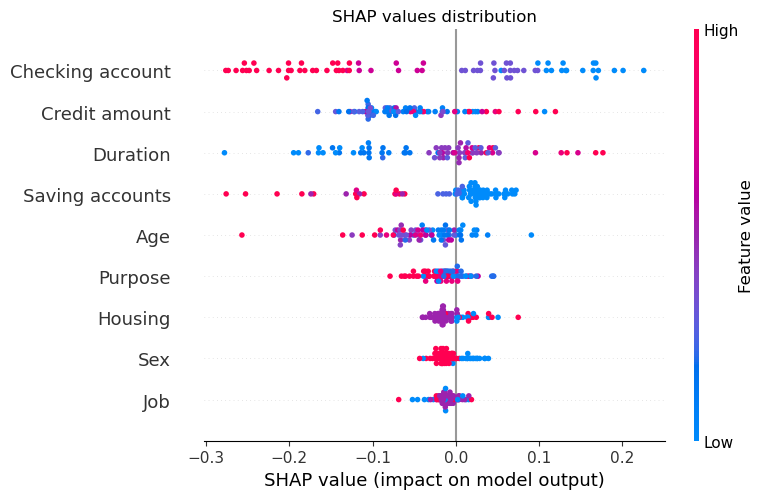

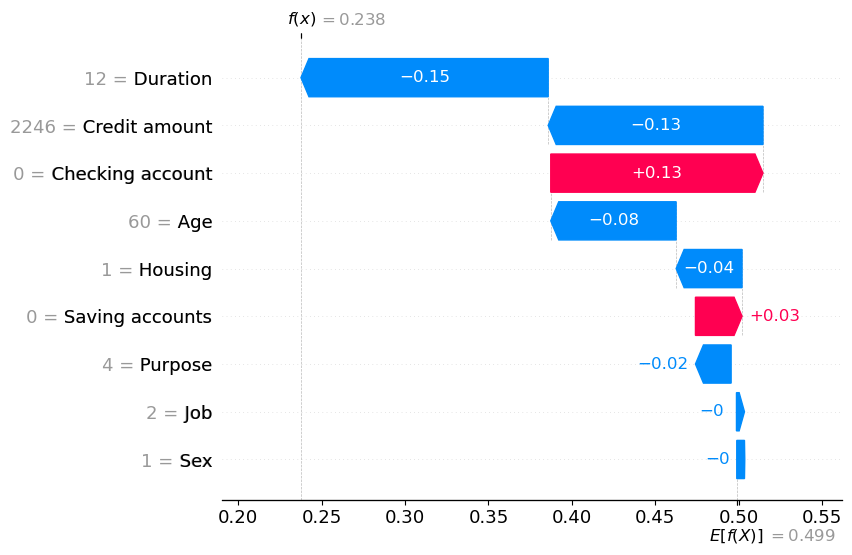

In [342]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_val_encoded)[:, :, 1]

# Summary plot - общая картина важности и направления влияния
shap.summary_plot(shap_values, X_val_encoded, plot_type="bar", show=False)
plt.title("SHAP feature importance")
plt.tight_layout()
plt.show()

# Подробный summary plot с распределением значений
shap.summary_plot(shap_values, X_val_encoded, show=False)
plt.title("SHAP values distribution")
plt.tight_layout()
plt.show()

# Waterfall plot для конкретного клиента
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0], 
        base_values=explainer.expected_value[0], 
        data=X_val_encoded.iloc[0].values, 
        feature_names=X_val_encoded.columns.tolist()
    )
)

### 1. SHAP summary plot (bar) — важность признаков

На первом графике показана **средняя абсолютная значимость SHAP для каждого признака**.

* **Checking account** — самый важный признак. Его влияние на прогноз сильное, соответствует IV, который также показывает высокую информативность (0.666).
* **Credit amount** и **Duration** занимают второе и третье место. Duration согласуется с IV (0.227), Credit amount имеет умеренное влияние, что также видно на графике SHAP.
* **Saving accounts** и **Age** — средняя значимость, отражают умеренное влияние на модель, также соответствуют IV (Saving accounts — 0.196, Age — 0.087).
* Остальные признаки (**Purpose, Housing, Sex, Job**) имеют низкую значимость, что совпадает с их низкими IV значениями.

Вывод: bar-plot подтверждает, что признаки с высокой IV оказывают сильное влияние на модель, а признаки с низкой IV — слабое.

---

### 2. SHAP summary plot (beeswarm) — распределение влияния

На втором графике показано распределение SHAP-значений для всех объектов:

* **Checking account**: красные точки (состояние текущего счета выше) уменьшают риск, синие точки (меньше состояние счета), наоборот, увеличивают риск.
* **Credit amount**: высокие значения увеличивают риск, и наоборот.
* **Duration**: более длительные кредиты увеличивают риск (красные точки смещены вправо), короткие — уменьшают.
* **Saving accounts и Age**: низкие значения увеличивают риск, высокие значения уменьшают риск.
* **Purpose, Housing, Sex, Job**: распределение SHAP почти симметричное и узкое, показывает слабое влияние на прогноз.

Вывод: beeswarm подтверждает **направление влияния признаков**, согласуется с ожиданиями IV и здравым смыслом.

---

### 3. SHAP waterfall plot — влияние на конкретный объект

На третьем графике показано, как признаки конкретного клиента двигают прогноз относительно базового значения модели:

* **Duration**: длительность всего 12 месяцев, снижает риск.
* **Credit amount**: небольшоая сумма (2246) так же снижает риск.
* **Checking account**: состояние текущего счета (0 - little) увеличивает риск.
* **Age, Housing, Saving accounts, Purpose**: влияние умеренное и разнонаправленное, показывает, что для конкретного клиента эти признаки чуть корректируют прогноз.
* **Job и Sex**: почти не влияют на индивидуальный прогноз.

Вывод: waterfall plot позволяет видеть **конкретное влияние каждого признака на прогноз клиента**, что полностью соответствует общей важности, показанной SHAP и IV.

---

**Общий вывод:** SHAP-графики полностью подтверждают выводы, сделанные на основе IV: признаки, которые являются сильными с точки зрения IV, оказывают наибольшее влияние на прогноз модели. SHAP позволяет дополнительно увидеть распределение влияния для всех объектов и конкретных клиентов, а также направленность этого влияния, что делает модель интерпретируемой и наглядной для задачи кредитного скоринга.

Checking account    0.665840
duration_bin        0.227157
Saving accounts     0.195941
amount_bin          0.093377
age_bin             0.086989
Housing             0.083260
Purpose             0.067310
Sex                 0.026514
Job                 0.008750

## Финальное тестирование модели

In [353]:
test_probs = rf_model.predict_proba(X_test_encoded)[:, 1]
test_pred = test_probs >= thresh # Используем порог, найденный на валидации

print(classification_report(y_test, test_pred))
print('ROC-AUC:', roc_auc_score(y_test, test_probs))
print('F-beta:', fbeta_score(y_test, test_pred, beta=2))

              precision    recall  f1-score   support

           0       0.92      0.43      0.59        53
           1       0.40      0.91      0.56        22

    accuracy                           0.57        75
   macro avg       0.66      0.67      0.57        75
weighted avg       0.77      0.57      0.58        75

ROC-AUC: 0.7885934819897085
F-beta: 0.7246376811594203


Финальная сравнительная таблица всех моделей



,ROC-AUC,F-beta,Recall
RandomForest,0.788593,0.724638,0.909091
XGBoost,0.777015,0.691057,0.772727
LightGBM,0.763293,0.661765,0.818182
CatBoost,0.781304,0.723684,1.0
LogReg (baseline),0.786449,0.72,0.818182


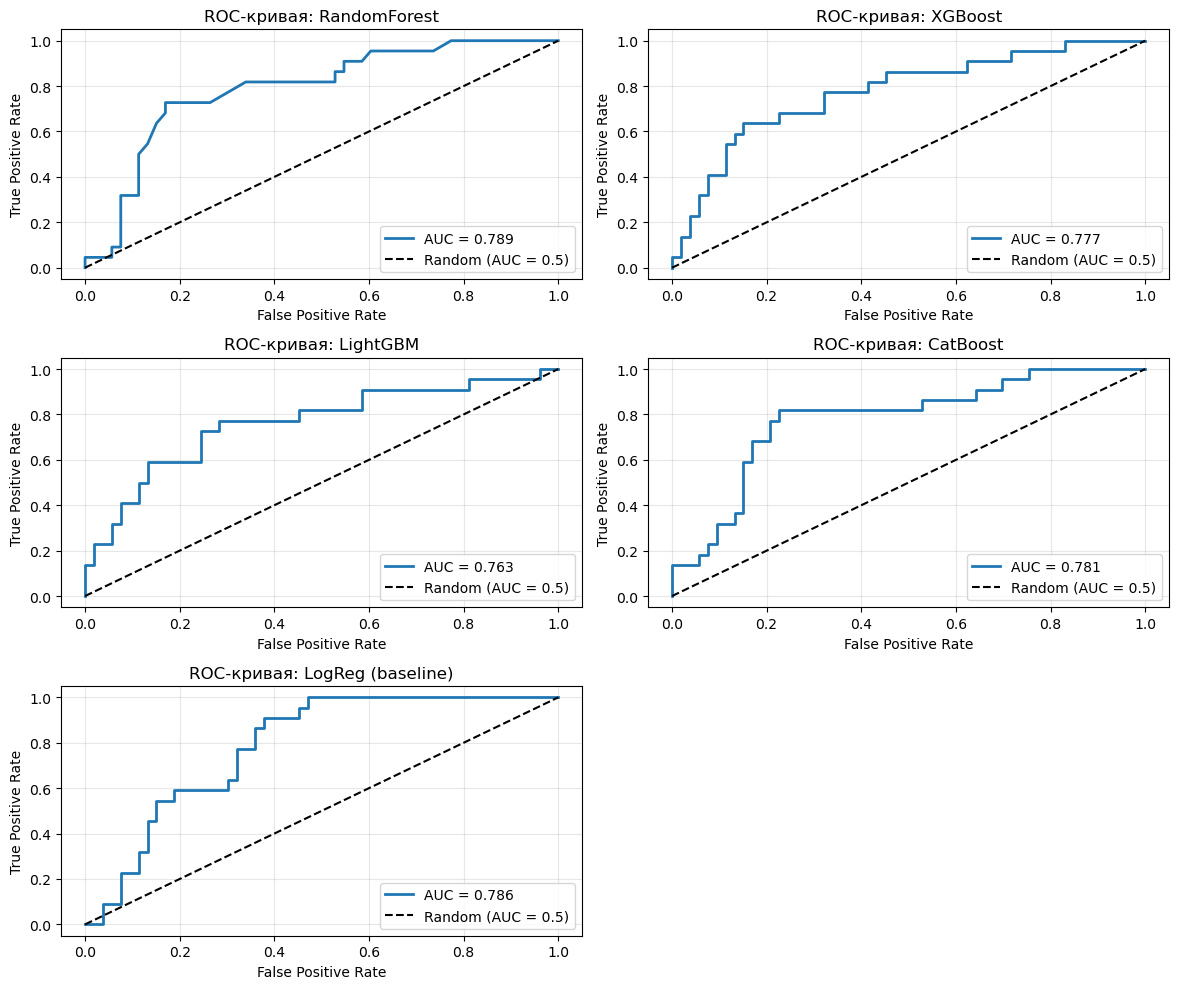

In [452]:
final_pivot = pd.DataFrame(index=models.keys(), columns=['ROC-AUC', 'F-beta', 'Recall'])

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):

    y_proba = model.predict_proba(X_test_encoded)[:, 1]
    threshold = results.loc[name, 'threshold']
    
    fbeta = fbeta_score(y_test, y_proba >= threshold, beta=2)
    recall = recall_score(y_test, y_proba >= threshold)
    
    final_pivot.loc[name] = [roc_auc_score(y_test, y_proba), fbeta, recall]
    
    roc_curve_plot(y_test, y_proba, axes[i])
    axes[i].set_title(f'ROC-кривая: {name}')


y_proba = log_reg.predict_proba(X_test)[:, 1]
threshold = 0.5
fbeta = fbeta_score(y_test, y_proba >= threshold, beta=2)
recall = recall_score(y_test, y_proba >= threshold)

final_pivot.loc['LogReg (baseline)'] = [roc_auc_score(y_test, y_proba), fbeta, recall]

roc_curve_plot(y_test, y_proba, axes[i+1])
axes[i+1].set_title(f'ROC-кривая: LogReg (baseline)')
plt.tight_layout()

# Скрываем лишние оси
for i in range(len(models)+1, 3*2):
    axes[i].axis('off')

print('Финальная сравнительная таблица всех моделей\n')
final_pivot

**Вывод по результатам тестирования всех моделей**

Представленные результаты на тестовой выборке подтверждают правильность выбора Random Forest в качестве финальной модели.

**Ключевые наблюдения:**

1. **Random Forest** подтверждает свое лидерство, показывая наилучший ROC-AUC (0.789) и максимальный F-beta (0.725) при высоком recall (0.909). Модель демонстрирует устойчивость результатов при переносе с валидации на тест.

2. **CatBoost** показывает сопоставимые результаты (F-beta 0.724, recall 1.0), что подтверждает качество альтернативного подхода, однако уступает по ROC-AUC.

3. **Baseline (LogReg)** неожиданно высок (F-beta 0.72), что говорит о хорошей предсказательной силе исходных признаков даже в линейной постановке.

4. **XGBoost** и **LightGBM** уступают лидерам по целевой метрике.

## Выводы

В результате проведенного исследования разработана модель кредитного скоринга, решающая задачу бинарной классификации для предсказания риска невозврата кредита.

**Разведочный анализ данных** выявил ключевые факторы, влияющие на риск: состояние текущего счета (Checking account), срок кредита (Duration) и наличие сбережений (Saving accounts). Важным открытием стала высокая информативность пропусков — клиенты с незаполненными полями в финансовых признаках продемонстрировали аномально низкий риск, что потребовало сохранения категории 'unknown' как отдельного значимого уровня.

**Сравнение пяти моделей** (Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost) показало, что Random Forest даже без оптимизации параметров достигает наилучшего качества:

**Финальные результаты на тестовой выборке:**

На тестовой выборке Random Forest показал высокое качество разделения классов и удовлетворяет бизнес-логике:

- **ROC-AUC = 0.789** — высокое качество разделения классов, значительно выше случайного уровня
- **F-beta (β=2) = 0.725** — целевая метрика подтверждает эффективность модели с приоритетом полноты
- **Recall класса 1 = 0.91** — модель выявляет 91% проблемных заемщиков
- **Precision класса 1 = 0.40** — из всех классифицированных как рисковые 40% действительно проблемные
- **Accuracy = 0.57** — общая точность

**Интерпретация:** Модель ориентирована на максимальный охват рисковых клиентов (91% выявления), даже ценой значительного числа ложных срабатываний (точность 40%). Это полностью соответствует задаче кредитного скоринга, где пропустить дефолтный кредит обходится дороже, чем ошибочно отказать надежному заемщику.

**Сравнение с базовым уровнем:**
- Logistic Regression (baseline): recall = 0.70, F-beta = 0.620
- **Random Forest (финальный): recall = 0.91, F-beta = 0.725** — значительное улучшение целевых метрик

**SHAP-анализ** подтвердил, что модель принимает решения, согласованные с бизнес-логикой и выводами EDA: Checking account и Duration являются ключевыми факторами риска, при этом сохраняется интерпретируемость предсказаний.

Разработанная модель готова к внедрению в кредитный конвейер банка для автоматизации принятия решений и минимизации финансовых потерь от невозвратов.